<a href="https://colab.research.google.com/github/lexinejazly-asuncion/Hallucination_Detection/blob/main/Hallucination_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
#Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Load Dataset
hall_dec_pd = pd.read_parquet("hf://datasets/PatronusAI/HaluBench/data/test-00000-of-00001.parquet")

In [20]:
hall_dec_pd.head()

,id,passage,question,answer,label,source_ds
0,d3fb4c3c-d21b-480a-baa0-98d6d0d17c1d,Hoping to rebound from the road loss to the Ch...,Which team scored the longest field goal kick ...,"['Rams', 'second', 'Marc Bulger', 'Kevin Curtis']",FAIL,DROP
1,8603663e-c53b-46db-a482-a867f12ff3b4,"As of the census of 2000, there were 218,590 p...",How many percent were not Irish?,87.1,FAIL,DROP
2,c63a73e5-2c91-489b-bd24-af150ddfa82c,Hoping to rebound from the road loss to the Ch...,How many yards was the second longest field go...,42,FAIL,DROP
3,52db14ed-5426-46ec-b0ae-4ef843b2d692,Hoping to rebound from their tough overtime ro...,How long was the last touchdown?,18-yard,FAIL,DROP
4,31b36417-aad1-412c-b0e5-9c1faaed233f,"As of the census of 2000, there were 218,590 p...",How many in percent from the census weren't Ir...,87.1,FAIL,DROP


In [21]:
hall_dec_pd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14900 entries, 0 to 14899
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         14900 non-null  object
 1   passage    14900 non-null  object
 2   question   14900 non-null  object
 3   answer     14900 non-null  object
 4   label      14900 non-null  object
 5   source_ds  14900 non-null  object
dtypes: object(6)
memory usage: 698.6+ KB


In [22]:
hall_dec_pd.describe()

,id,passage,question,answer,label,source_ds
count,14900,14900,14900,14900,14900,14900
unique,14900,12419,13798,13543,2,6
top,covidqa-1538,Chikungunya: A Potentially Emerging Epidemic?\...,leasing meaning,yes,PASS,halueval
freq,1,67,6,159,7730,10000


In [23]:
def check_missing_values(df):
  return df.isnull().sum()

print(check_missing_values(hall_dec_pd))

id           0
passage      0
question     0
answer       0
label        0
source_ds    0
dtype: int64


In [28]:
# ── 3. EXTREME OUTLIERS ─────────────────────────────────────
def find_extreme_outliers(df, col):
    return df[df[col] > df[col].quantile(0.95)]

outliers = find_extreme_outliers(hall_dec_pd, "passage_len")
print(f"\nExtreme outliers (top 5% by passage length): {len(outliers)} rows")
print(outliers[["question", "passage_len", "answer_len", "label"]].head())


Extreme outliers (top 5% by passage length): 735 rows
                                                question  passage_len  \
13900                      How will  this approach used?         2391   
13901  What is the percentage reduction in pneumonia ...         3616   
13902  In addition to oral swabs, which tests detecte...         2231   
13905                   What is it vectored by, in Asia?         3862   
13907                          What did this model show?         3220   

       answer_len label  
13900          36  FAIL  
13901          75  PASS  
13902          21  PASS  
13905           5  FAIL  
13907          26  FAIL  



Class Distribution:
label
PASS    7730
FAIL    7170
Name: count, dtype: int64
Imbalance ratio: 1.08x


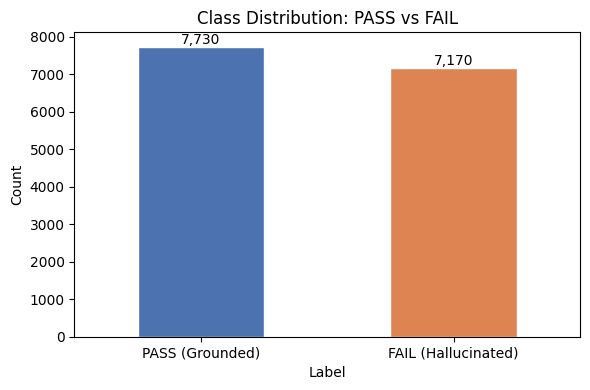

In [29]:
# ── 4. CLASS BALANCE ────────────────────────────────────────
label_counts = hall_dec_pd["label"].value_counts()
print(f"\nClass Distribution:\n{label_counts}")
print(f"Imbalance ratio: {label_counts.max() / label_counts.min():.2f}x")

fig, ax = plt.subplots(figsize=(6, 4))
label_counts.plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452"], edgecolor="white")
ax.set_title("Class Distribution: PASS vs FAIL")
ax.set_xlabel("Label")
ax.set_ylabel("Count")
ax.set_xticklabels(["PASS (Grounded)", "FAIL (Hallucinated)"], rotation=0)
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}",
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom")
plt.tight_layout()
plt.show()

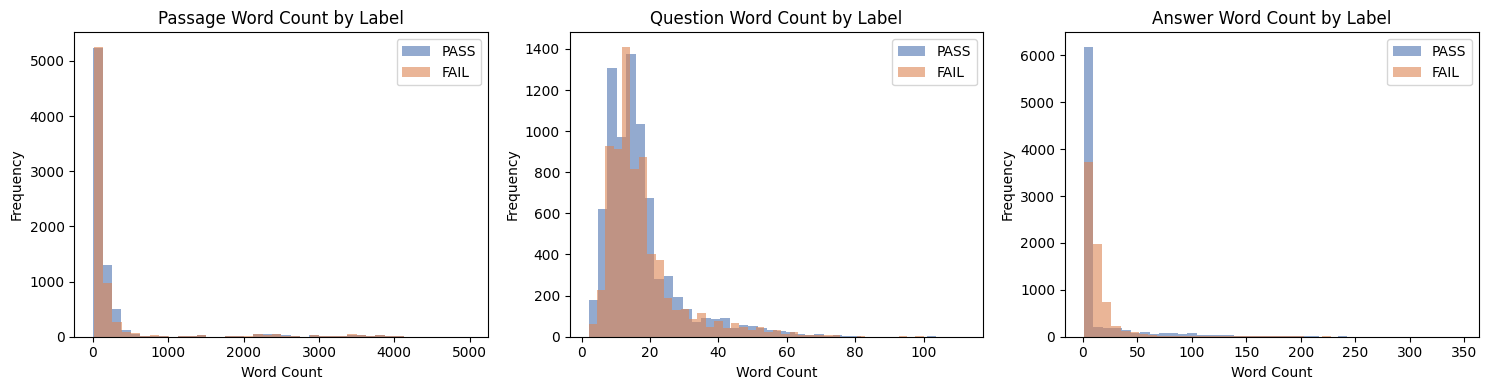


Mean lengths by label:
       passage_len  question_len  answer_len
label                                       
FAIL         273.6          17.6        15.1
PASS         272.3          17.0        15.1


In [30]:
# ── 5. TEXT LENGTH DISTRIBUTIONS ────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fields = [("passage_len", "Passage"), ("question_len", "Question"), ("answer_len", "Answer")]

for ax, (col, label) in zip(axes, fields):
    for lbl, color in [("PASS", "#4C72B0"), ("FAIL", "#DD8452")]:
        subset = hall_dec_pd[hall_dec_pd["label"] == lbl][col]
        ax.hist(subset, bins=40, alpha=0.6, label=lbl, color=color)
    ax.set_title(f"{label} Word Count by Label")
    ax.set_xlabel("Word Count")
    ax.set_ylabel("Frequency")
    ax.legend()

plt.tight_layout()
plt.show()

print("\nMean lengths by label:")
print(hall_dec_pd.groupby("label")[["passage_len","question_len","answer_len"]].mean().round(1))


Samples by domain:
source_ds
halueval        10000
DROP             1000
pubmedQA         1000
FinanceBench     1000
covidQA          1000
RAGTruth          900
Name: count, dtype: int64

Hallucination rate (%) by domain:
source_ds
halueval        50.1
DROP            50.0
FinanceBench    50.0
covidQA         50.0
pubmedQA        50.0
RAGTruth        17.8
Name: label, dtype: float64


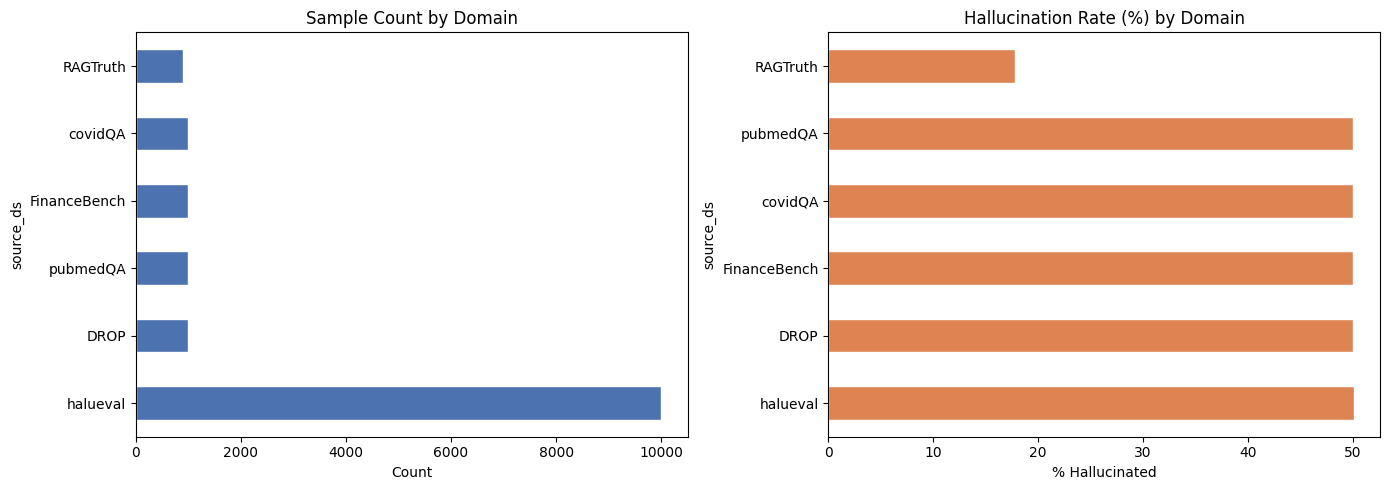

In [31]:
# ── 6. DOMAIN BREAKDOWN ─────────────────────────────────────
domain_counts = hall_dec_pd["source_ds"].value_counts()
print(f"\nSamples by domain:\n{domain_counts}")

hall_rate = hall_dec_pd.groupby("source_ds")["label"].apply(
    lambda x: (x == "FAIL").sum() / len(x) * 100
).sort_values(ascending=False).round(1)
print(f"\nHallucination rate (%) by domain:\n{hall_rate}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

domain_counts.plot(kind="barh", ax=axes[0], color="#4C72B0", edgecolor="white")
axes[0].set_title("Sample Count by Domain")
axes[0].set_xlabel("Count")

hall_rate.plot(kind="barh", ax=axes[1], color="#DD8452", edgecolor="white")
axes[1].set_title("Hallucination Rate (%) by Domain")
axes[1].set_xlabel("% Hallucinated")

plt.tight_layout()
plt.show()

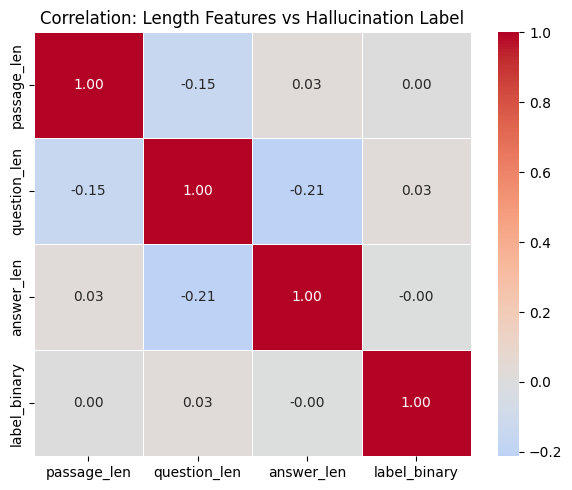

In [32]:
# ── 7. CORRELATION HEATMAP ──────────────────────────────────
hall_dec_pd["label_binary"] = (hall_dec_pd["label"] == "FAIL").astype(int)
corr = hall_dec_pd[["passage_len", "question_len", "answer_len", "label_binary"]].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5, ax=ax)
ax.set_title("Correlation: Length Features vs Hallucination Label")
plt.tight_layout()
plt.show()


In [33]:
# ── 8. SUMMARY PRINT ────────────────────────────────────────
print("=" * 50)
print("EDA SUMMARY")
print("=" * 50)
print(f"Total samples:       {len(hall_dec_pd):,}")
print(f"PASS (grounded):     {label_counts.get('PASS', 0):,}")
print(f"FAIL (hallucinated): {label_counts.get('FAIL', 0):,}")
print(f"Imbalance ratio:     {label_counts.max() / label_counts.min():.2f}x")
print(f"Avg passage length:  {hall_dec_pd['passage_len'].mean():.0f} words")
print(f"Avg answer length:   {hall_dec_pd['answer_len'].mean():.0f} words")
print(f"Domains covered:     {hall_dec_pd['source_ds'].nunique()}")
print(f"Hardest domain:      {hall_rate.idxmax()} ({hall_rate.max()}% hallucinated)")


EDA SUMMARY
Total samples:       14,900
PASS (grounded):     7,730
FAIL (hallucinated): 7,170
Imbalance ratio:     1.08x
Avg passage length:  273 words
Avg answer length:   15 words
Domains covered:     6
Hardest domain:      halueval (50.1% hallucinated)
